In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# agar tabel tampil lengkap
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

df = pd.read_csv("sample_data_17-03-2026.csv")

# lihat 5 data pertama
print("5 data pertama:")
print(df.head())

print("\nInfo dataset:")
print(df.info())

print("\nJumlah missing values:")
print(df.isna().sum())

5 data pertama:
                                                                    name  \
0  Apple MacBook Air M1 Chip 2020 256GB / 512GB SPACE GRAY, GOLD, SILVER   
1  ULTRABOOK DELL LATITUDE 7300 i7-8650 / 16GB RAM / SSS 512GB NVME/ IPS   
2             Lenovo V14 G2 Ryzen 3 5300U 256GB SSD 4GB Win+OHS Original   
3        Laptop Lenovo IdeaPad Slim 3i i3-1115G4 512GB SSD 8GB Win10+OHS   
4       Apple MacBook Pro M1 Pro 2021 14" 512GB / 1TB SPACE GRAY, SILVER   

          price       location  rating           sold  \
0  Rp13.399.000  Jakarta Pusat     4.9  Terjual 2 rb+   
1   Rp3.850.000     Kab. Bogor     5.0      Terjual 5   
2   Rp5.899.000  Jakarta Barat     5.0   Terjual 100+   
3   Rp6.899.000      Tangerang     5.0   Terjual 250+   
4  Rp26.390.000  Jakarta Pusat     4.9   Terjual 250+   

                                                                                                              details_link  
0  https://ta.tokopedia.com/promo/v1/clicks/8a-xgVY2gmUEopj

In [ ]:
# 3. COPY DATA AGAR DATA ASLI TETAP AMAN
data = df.copy()

In [ ]:
# 4. DATA CLEANING
# --------------------------------------------

# 4.1 Bersihkan kolom price
# contoh: "Rp12.254.999" -> 12254999
data['price_clean'] = (
    data['price']
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

data['price_clean'] = pd.to_numeric(data['price_clean'], errors='coerce')

# 4.2 Bersihkan kolom sold
# contoh:
# "Terjual 500+" -> 500
# "Terjual 2" -> 2
def clean_sold(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    x = x.replace("terjual", "").replace("+", "").strip()
    x = x.replace(".", "").replace(",", "")
    try:
        return float(x)
    except:
        return np.nan

data['sold_clean'] = data['sold'].apply(clean_sold)

# 4.3 Isi missing rating dengan median
data['rating'] = data['rating'].fillna(data['rating'].median())

# 4.4 Isi missing sold dengan 0
data['sold_clean'] = data['sold_clean'].fillna(0)

# 4.5 Standarkan nama lokasi
data['location'] = data['location'].astype(str).str.strip()

print("\nData setelah cleaning:")
print(data[['name', 'price', 'price_clean', 'rating', 'sold', 'sold_clean']].head())


Data setelah cleaning:
                                                                    name  \
0  Apple MacBook Air M1 Chip 2020 256GB / 512GB SPACE GRAY, GOLD, SILVER   
1  ULTRABOOK DELL LATITUDE 7300 i7-8650 / 16GB RAM / SSS 512GB NVME/ IPS   
2             Lenovo V14 G2 Ryzen 3 5300U 256GB SSD 4GB Win+OHS Original   
3        Laptop Lenovo IdeaPad Slim 3i i3-1115G4 512GB SSD 8GB Win10+OHS   
4       Apple MacBook Pro M1 Pro 2021 14" 512GB / 1TB SPACE GRAY, SILVER   

          price  price_clean  rating           sold  sold_clean  
0  Rp13.399.000     13399000     4.9  Terjual 2 rb+         0.0  
1   Rp3.850.000      3850000     5.0      Terjual 5         5.0  
2   Rp5.899.000      5899000     5.0   Terjual 100+       100.0  
3   Rp6.899.000      6899000     5.0   Terjual 250+       250.0  
4  Rp26.390.000     26390000     4.9   Terjual 250+       250.0  


In [ ]:
# 5. EKSTRAK MEREK LAPTOP DARI NAMA PRODUK
# --------------------------------------------
def get_brand(name):
    name = str(name).upper()

    if "APPLE" in name or "MACBOOK" in name:
        return "Apple"
    elif "ASUS" in name:
        return "ASUS"
    elif "LENOVO" in name:
        return "Lenovo"
    elif "ACER" in name:
        return "Acer"
    elif "DELL" in name:
        return "Dell"
    elif "HP" in name or "PAVILION" in name or "PROBOOK" in name or "ELITEBOOK" in name:
        return "HP"
    elif "MSI" in name:
        return "MSI"
    elif "XIAOMI" in name or "REDMI" in name:
        return "Xiaomi"
    elif "SAMSUNG" in name:
        return "Samsung"
    elif "AXIOO" in name:
        return "Axioo"
    elif "INFINIX" in name:
        return "Infinix"
    elif "TECNO" in name:
        return "Tecno"
    elif "ADVAN" in name:
        return "Advan"
    elif "FUJITSU" in name:
        return "Fujitsu"
    elif "TOSHIBA" in name:
        return "Toshiba"
    else:
        return "Lainnya"

data['brand'] = data['name'].apply(get_brand)

print("\nJumlah data per brand:")
print(data['brand'].value_counts())


Jumlah data per brand:
brand
ASUS       47
Lenovo     45
Acer       18
Apple      14
HP         12
Xiaomi      9
Dell        7
Infinix     4
MSI         2
Samsung     1
Lainnya     1
Name: count, dtype: int64


In [ ]:
# 6. BUAT KATEGORI HARGA
# --------------------------------------------
def price_category(price):
    if price < 5000000:
        return "< 5 Juta"
    elif price < 10000000:
        return "5 - 10 Juta"
    elif price < 15000000:
        return "10 - 15 Juta"
    elif price < 20000000:
        return "15 - 20 Juta"
    else:
        return "> 20 Juta"

data['price_category'] = data['price_clean'].apply(price_category)

print("\nDistribusi kategori harga:")
print(data['price_category'].value_counts())


Distribusi kategori harga:
price_category
5 - 10 Juta     65
< 5 Juta        51
10 - 15 Juta    32
15 - 20 Juta     7
> 20 Juta        5
Name: count, dtype: int64


In [ ]:
# 7. RANKING LAPTOP TERLARIS
# --------------------------------------------
# urutkan berdasarkan sold_clean terbesar, lalu rating tertinggi, lalu harga
top_laptops = data.sort_values(
    by=['sold_clean', 'rating', 'price_clean'],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\nTop 10 laptop terlaris:")
print(top_laptops[['name', 'brand', 'price_clean', 'rating', 'sold_clean', 'location']].head(10))


Top 10 laptop terlaris:
                                                                     name  \
0            Lenovo Slim D330 Flex TOUCH N4020 8GB 128GB W10Pro 10.1 GREY   
1    ACER ASPIRE 3 A314-35 QUADCORE N5100 4GB 256GB INTEL UHD 14" OHS W10   
2   Acer Aspire 3 Slim A314-22 AMD Athlon 3050U 4GB 256GB 14" FHD W10 OHS   
3  ASUS M415DAO VIPS352 Ryzen 3 3250 8GB 512ssd Vega3 W10+OHS 14.0FHD IPS   
4  Asus M415DAO VIPS352 Ryzen 3 3250 8GB 512ssd Vega3 W10+OHS 14.0FHD IPS   
5   ASUS TUF GAMING F15 FX506LH i5-10300H 8GB 512GB GTX1650 4GB W10 144HZ   
6   Lenovo Ideapad Gaming 3 Ryzen 5 5600 8GB 512SSD GTX1650 4GB W11 120Hz   
7     Lenovo Ideapad Gaming 3 GeForce RTX™ 3050 - Ryzen 5 5600 8GB 512SSD   
8                       HP 14S DQ0508TU N4120 4GB 256SSD W10+OHS 14.0 2YR   
9         Asus vivobook A416JAO FHD322 i3 1005G1 4GB 256ssd W10+OHS 14FHD   

    brand  price_clean  rating  sold_clean       location  
0  Lenovo      3599000     4.9       750.0  Jakarta Utara  
1    Ac

In [ ]:
# 8. ANALISIS BRAND
# --------------------------------------------
brand_summary = data.groupby('brand').agg(
    jumlah_produk=('name', 'count'),
    total_terjual=('sold_clean', 'sum'),
    rata_rating=('rating', 'mean'),
    rata_harga=('price_clean', 'mean')
).sort_values(by='total_terjual', ascending=False)

print("\nRingkasan brand:")
print(brand_summary)


Ringkasan brand:
         jumlah_produk  total_terjual  rata_rating    rata_harga
brand                                                           
ASUS                47        12323.0     4.938298  8.417919e+06
Lenovo              45         6269.0     4.931111  8.081465e+06
Acer                18         2608.0     4.933333  6.245083e+06
Apple               14         2304.0     4.928571  1.595064e+07
Xiaomi               9         1650.0     4.966667  4.930337e+06
HP                  12          860.0     4.925000  6.579000e+06
Infinix              4          712.0     4.950000  5.239000e+06
Lainnya              1          250.0     4.900000  7.029000e+06
MSI                  2          200.0     4.950000  6.499500e+06
Dell                 7          145.0     4.914286  4.809571e+06
Samsung              1            0.0     4.900000  1.899000e+06


In [ ]:
# 9. ANALISIS KATEGORI HARGA
# --------------------------------------------
price_summary = data.groupby('price_category').agg(
    jumlah_produk=('name', 'count'),
    total_terjual=('sold_clean', 'sum'),
    rata_rating=('rating', 'mean'),
    rata_harga=('price_clean', 'mean')
).sort_values(by='total_terjual', ascending=False)

print("\nRingkasan kategori harga:")
print(price_summary)


Ringkasan kategori harga:
                jumlah_produk  total_terjual  rata_rating    rata_harga
price_category                                                         
5 - 10 Juta                65        11742.0     4.935385  7.247648e+06
< 5 Juta                   51         8121.0     4.935294  3.816147e+06
10 - 15 Juta               32         5348.0     4.931250  1.220866e+07
15 - 20 Juta                7         1600.0     4.914286  1.756371e+07
> 20 Juta                   5          510.0     4.960000  2.311120e+07


In [ ]:
# 10. ANALISIS LOKASI
# --------------------------------------------
location_summary = data.groupby('location').agg(
    jumlah_produk=('name', 'count'),
    total_terjual=('sold_clean', 'sum'),
    rata_rating=('rating', 'mean')
).sort_values(by='total_terjual', ascending=False)

print("\nTop 10 lokasi dengan penjualan tertinggi:")
print(location_summary.head(10))


Top 10 lokasi dengan penjualan tertinggi:
                    jumlah_produk  total_terjual  rata_rating
location                                                     
Jakarta Utara                  62        13415.0     4.932258
Jakarta Pusat                  65        10947.0     4.933846
Jakarta Barat                  16         2060.0     4.950000
Jakarta Selatan                 4          470.0     4.950000
Tangerang                       2          280.0     5.000000
Jakarta Timur                   1           60.0     5.000000
Dilayani Tokopedia              1           30.0     5.000000
Kab. Bogor                      3           25.0     4.866667
Batam                           2           24.0     4.950000
Semarang                        1            9.0     4.700000


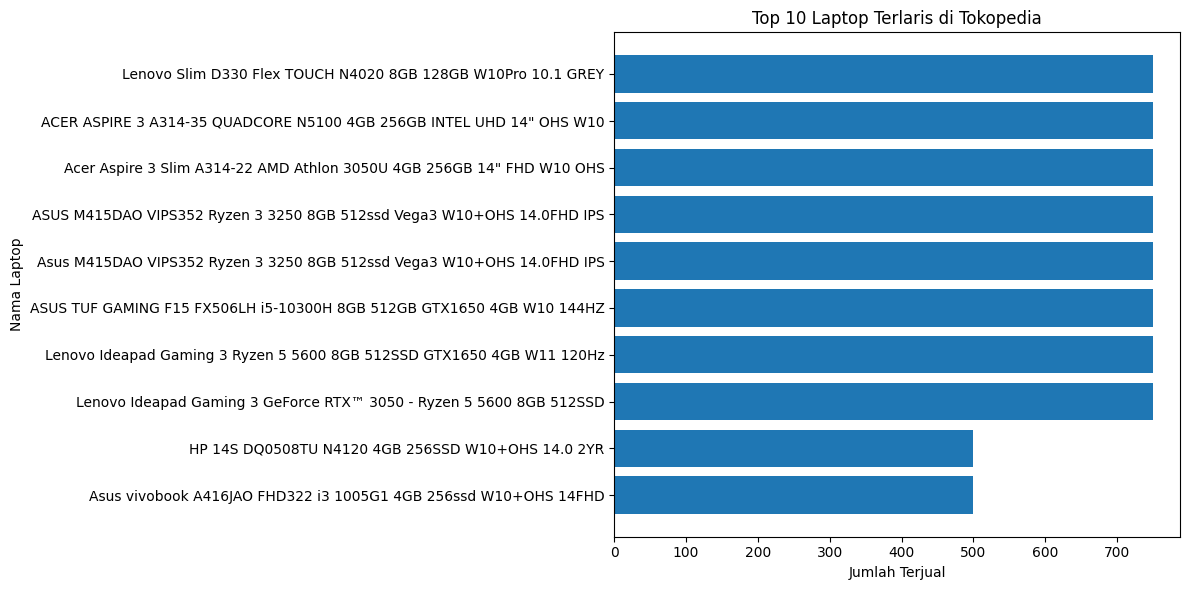

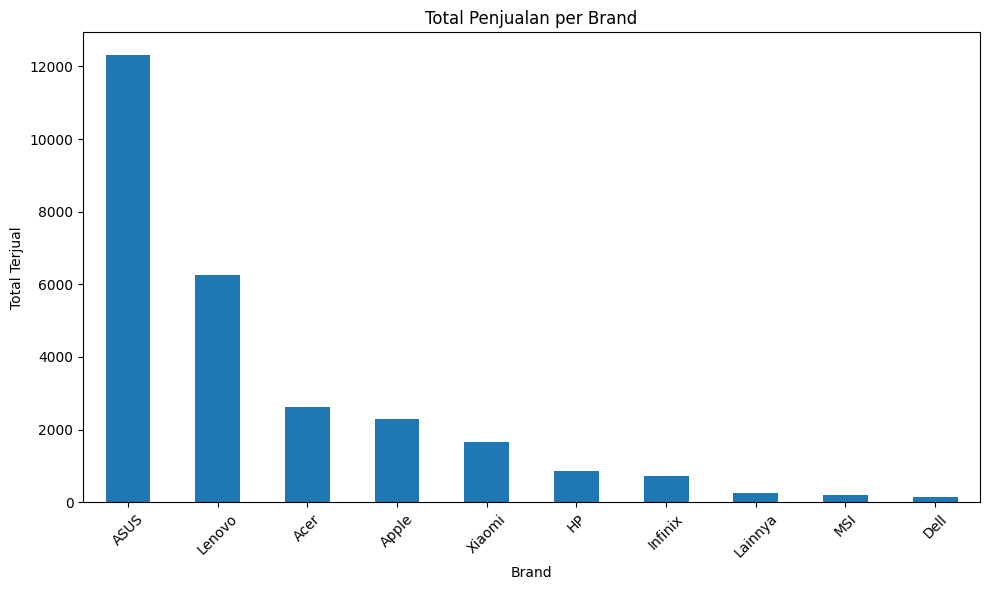

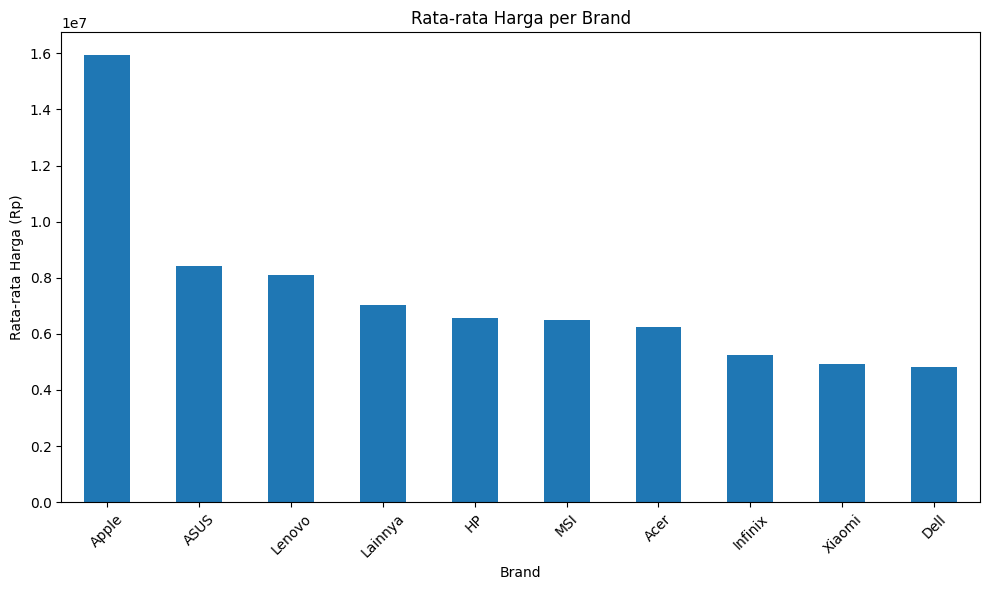

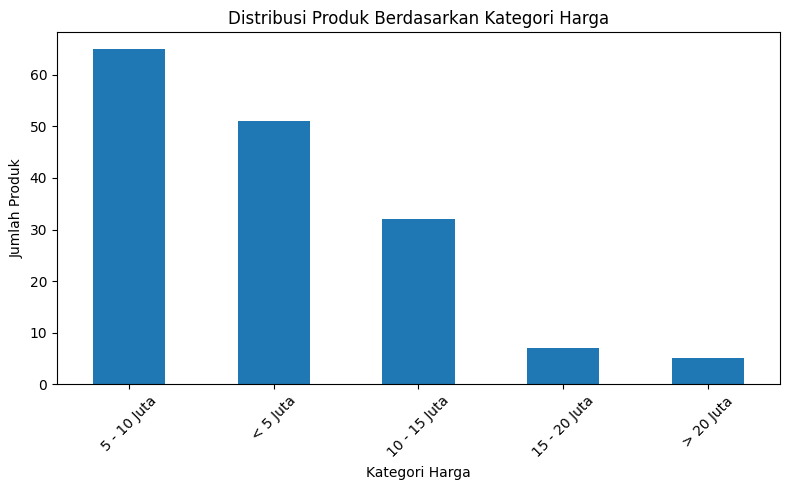

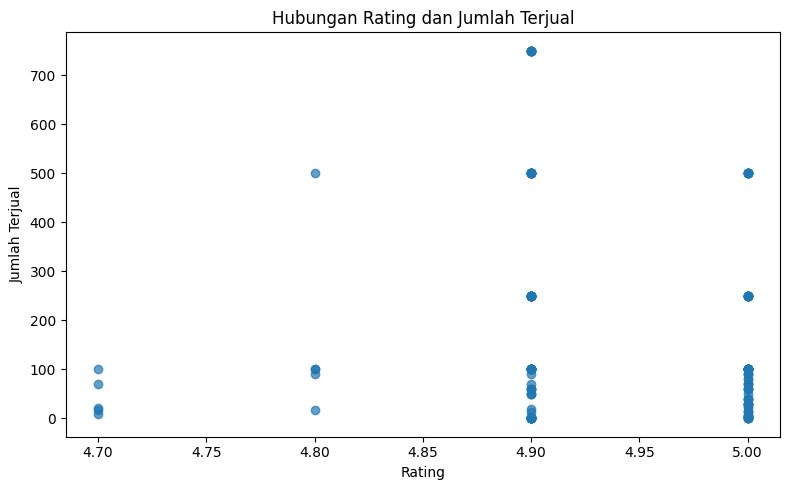

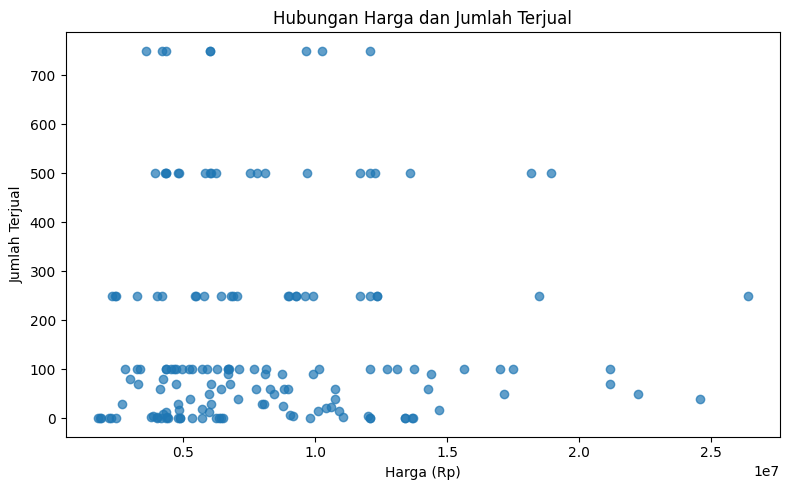

In [ ]:
# 11. VISUALISASI
# --------------------------------------------

# 11.1 Top 10 laptop terlaris
top10 = top_laptops.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10['name'][::-1], top10['sold_clean'][::-1])
plt.title('Top 10 Laptop Terlaris di Tokopedia')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Nama Laptop')
plt.tight_layout()
plt.show()

# 11.2 Total penjualan per brand
plt.figure(figsize=(10, 6))
brand_summary['total_terjual'].head(10).plot(kind='bar')
plt.title('Total Penjualan per Brand')
plt.xlabel('Brand')
plt.ylabel('Total Terjual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11.3 Rata-rata harga per brand
plt.figure(figsize=(10, 6))
brand_summary['rata_harga'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Rata-rata Harga per Brand')
plt.xlabel('Brand')
plt.ylabel('Rata-rata Harga (Rp)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11.4 Distribusi kategori harga
plt.figure(figsize=(8, 5))
data['price_category'].value_counts().plot(kind='bar')
plt.title('Distribusi Produk Berdasarkan Kategori Harga')
plt.xlabel('Kategori Harga')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11.5 Rating vs jumlah terjual
plt.figure(figsize=(8, 5))
plt.scatter(data['rating'], data['sold_clean'], alpha=0.7)
plt.title('Hubungan Rating dan Jumlah Terjual')
plt.xlabel('Rating')
plt.ylabel('Jumlah Terjual')
plt.tight_layout()
plt.show()

# 11.6 Harga vs jumlah terjual
plt.figure(figsize=(8, 5))
plt.scatter(data['price_clean'], data['sold_clean'], alpha=0.7)
plt.title('Hubungan Harga dan Jumlah Terjual')
plt.xlabel('Harga (Rp)')
plt.ylabel('Jumlah Terjual')
plt.tight_layout()
plt.show()

In [ ]:
# 12. PRODUK TERLARIS PER BRAND
# --------------------------------------------
top_per_brand = data.sort_values(
    by=['brand', 'sold_clean', 'rating'],
    ascending=[True, False, False]
).groupby('brand').head(1)

print("\nProduk terlaris dari tiap brand:")
print(top_per_brand[['brand', 'name', 'price_clean', 'rating', 'sold_clean', 'location']])


Produk terlaris dari tiap brand:
       brand  \
22      ASUS   
18      Acer   
121    Apple   
156     Dell   
134       HP   
142  Infinix   
71   Lainnya   
51    Lenovo   
26       MSI   
6    Samsung   
10    Xiaomi   

                                                                       name  \
22   ASUS M415DAO VIPS352 Ryzen 3 3250 8GB 512ssd Vega3 W10+OHS 14.0FHD IPS   
18     ACER ASPIRE 3 A314-35 QUADCORE N5100 4GB 256GB INTEL UHD 14" OHS W10   
121                 MacBook Air 2020 Apple M1 Chip 13 Inch 8GB 256GB MGND63   
156         Dell Vostro 3405 [R5-3500U-4-256-UMA-W10-OHS-BLK] DELL OFFICIAL   
134                       HP 14S DQ0508TU N4120 4GB 256SSD W10+OHS 14.0 2YR   
142             Infinix Laptop X1 i3 1035G1 8GB 256SSD W10+Office 365 14.0"   
71        HUAWEI MateBook D15 i3-1115G4 Laptop [8+256GB] | Win 11 | Wi-Fi 6   
51      Lenovo Ideapad Gaming 3 GeForce RTX™ 3050 - Ryzen 5 5600 8GB 512SSD   
26   MSI Modern 14 C11M i3-1115G4 UHD Graphics 14" FHD IPS-Lev

In [ ]:
# 13. SKOR POPULARITAS (OPSIONAL)
# --------------------------------------------
# Bisa dipakai kalau dosen minta ranking yang mempertimbangkan lebih dari satu faktor
# Normalisasi min-max
data['sold_norm'] = (data['sold_clean'] - data['sold_clean'].min()) / (data['sold_clean'].max() - data['sold_clean'].min() + 1e-9)
data['rating_norm'] = (data['rating'] - data['rating'].min()) / (data['rating'].max() - data['rating'].min() + 1e-9)

# skor popularitas: bobot penjualan 70%, rating 30%
data['popularity_score'] = (0.7 * data['sold_norm']) + (0.3 * data['rating_norm'])

popular_products = data.sort_values(by='popularity_score', ascending=False)

print("\nTop 10 produk berdasarkan popularity score:")
print(popular_products[['name', 'brand', 'price_clean', 'rating', 'sold_clean', 'popularity_score']].head(10))


Top 10 produk berdasarkan popularity score:
                                                                       name  \
22   ASUS M415DAO VIPS352 Ryzen 3 3250 8GB 512ssd Vega3 W10+OHS 14.0FHD IPS   
18     ACER ASPIRE 3 A314-35 QUADCORE N5100 4GB 256GB INTEL UHD 14" OHS W10   
125            Lenovo Slim D330 Flex TOUCH N4020 8GB 128GB W10Pro 10.1 GREY   
91   Asus M415DAO VIPS352 Ryzen 3 3250 8GB 512ssd Vega3 W10+OHS 14.0FHD IPS   
51      Lenovo Ideapad Gaming 3 GeForce RTX™ 3050 - Ryzen 5 5600 8GB 512SSD   
55    Lenovo Ideapad Gaming 3 Ryzen 5 5600 8GB 512SSD GTX1650 4GB W11 120Hz   
40    ASUS TUF GAMING F15 FX506LH i5-10300H 8GB 512GB GTX1650 4GB W10 144HZ   
42    Acer Aspire 3 Slim A314-22 AMD Athlon 3050U 4GB 256GB 14" FHD W10 OHS   
87    Asus TUF A15 FA506IC R735B6TO Ryzen 7 4800 8GB 512ssd RTX3050 4GB W10   
90      ASUS VIVOBOOK 15 A516JAO i3-1005G1 DDR4 4GB SSD 256GB 15.6″ W10 OHS   

      brand  price_clean  rating  sold_clean  popularity_score  
22     ASUS      601